# Lab 3: Inverse Kinematics (worked solutions)

Companion to `InverseKinematicsTemplate.ipynb` and `pdfs/Inverse_Kinematics.pdf`.
Layout: **Task → Solution → How it works → Example / check**.

**What the lab is about.** Forward kinematics (FK) maps joint angles $q$ to a pose $T(q)$. Inverse kinematics (IK)
asks the reverse: which $q$ gives a wanted pose $T_{target}$? There can be several answers (elbow up/down,
wrist flipped), none (out of reach), or answers that need joints beyond their limits. So we solve it
**numerically**: start from a guess (the *seed*) and improve it step by step until the pose error is small.

**Data in this notebook.** The template needs `mycobot_280_gazebo.urdf`. It is not in the repo yet, so the notebook
uses the fallback URDF from `labpaths` (see the warning it prints). The fallback is almost certainly the same
robot geometry as the course file (Lab 5 reproduces the controller's calibration with it to six digits), so the numbers
written in the explanations ("in this run…") should also be what you see with the course file. If yours differ,
trust the printed output and re-read the reasoning, not the quoted numbers.

The last task (18) can move the real robot. It was **not executed** here and is switched off by default.

## Setup

In [1]:
%matplotlib widget
import os
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

from spatialmath import SE3
from scipy.optimize import least_squares, minimize

import labpaths          # solutions/labpaths.py: repo root on sys.path + URDF location
from helperFunctions import poseError, calculate_poseerror, transform_to_pipi, rpy_to_rot, rpy_to_transform

np.set_printoptions(precision=4, suppress=True)

**How it works**
- `least_squares` and `minimize` come from `scipy.optimize`: general-purpose numerical optimisers. We give them a
  function of $q$ and they search for the $q$ that makes it small.
- `helperFunctions.py` (in the repo root) contains the pose-error code shared with the robot controller.
  Its functions are used in every task, so here is what each does:

| function | what it does |
|---|---|
| `rpy_to_rot(rpy)` | $[roll, pitch, yaw] \to R = R_z(yaw)R_y(pitch)R_x(roll)$ (3×3) |
| `rpy_to_transform(xyz, rpy)` | 4×4 transform from position + RPY |
| `rot_to_vec(R)` | rotation matrix → **axis-angle vector** (axis × angle, 3 numbers) |
| `poseError(target, achieved)` | 6-vector `[target_pos − achieved_pos, rot_to_vec(R_target R_achievedᵀ)]` |
| `calculate_poseerror(q, robot, bodyname, targetpose, weights)` | runs FK at `q`, returns the weighted `poseError` |
| `transform_to_pipi(q)` | wraps angles into $[-\pi, \pi]$ |

  Why the rotation error is `R_target @ R_achievedᵀ`: it is the rotation that turns the achieved orientation into
  the target one, **expressed in the base frame**, and the Jacobian `jacob0` is also in the base frame. So error and
  Jacobian fit together.

---
## Task 1: Import the URDF model

In [2]:
mycobot_urdf_path = labpaths.urdf_path()     # template: os.path.join(os.getcwd(), 'mycobot_280_gazebo.urdf')
mycobot = rtb.Robot.URDF(mycobot_urdf_path)
print(mycobot)

for link in mycobot.links:
    print(link.name)

NOTE: mycobot_280_gazebo.urdf not found in the repo root.
      Using the fallback /home/mano-ub22/TUD/cobots/ros2_ws/src/mycobot_description/urdf/mycobot_280_pi/mycobot_280_pi.urdf
      (same kinematic chain as far as checked, see solutions/labpaths.py)
ERobot: firefighter, 6 joints (RRRRRR), geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ g_base         │       │ BASE   │ SE3()                                               │
│    1 │ joint1         │       │ g_base │ SE3()                                               │
│    2 │ joint2         │     0 │ joint1 │ SE3(0, 0, 0.1396) ⊕ Rz(q0)                          │
│    3 │ joint3         │     1 │ joint2 │ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1)          │
│    

/tmp/ipykernel_62044/3513415727.py:2: DeprecationWarning: Robot.URDF() is deprecated. Subclass roboticstoolbox.models.URDF.URDFRobot, or call URDF_read() from that module and construct Robot directly.
  mycobot = rtb.Robot.URDF(mycobot_urdf_path)


**How it works**
- `rtb.Robot.URDF(path)` reads the URDF (XML) and builds the kinematic tree.
- `mycobot.links` is a Python **list** of `Link` objects; `for link in mycobot.links:` visits them one by one,
  `link.name` is the string from the URDF.
- The chain: `g_base → joint1 → … → joint6 → joint6_flange`. IK is solved from `g_base` to `joint6_flange`
  (`mycobot.base_link`, `mycobot.ee_links[0]`).

---
## Task 2: The chain used for IK

In [3]:
bodyname = 'joint6_flange'
mycobot_ets = mycobot.ets(end=bodyname)
print(mycobot_ets)
print(f'Number of joints: {mycobot.n}')

SE3() ⊕ SE3(0, 0, 0.1396) ⊕ Rz(q0) ⊕ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1) ⊕ SE3(-0.1104, 0, 0) ⊕ Rz(q2) ⊕ SE3(-0.096, 0, 0.06462; 0°, -0°, -90°) ⊕ Rz(q3) ⊕ SE3(0, -0.07318, -0.001; -90°, -90°, 180°) ⊕ Rz(q4) ⊕ SE3(0, 0.0456, 0; -90°, -0°, 0°) ⊕ Rz(q5)
Number of joints: 6


**How it works**
- `mycobot.ets(end='joint6_flange')` returns the **elementary transform sequence** (ETS) from the base to that link:
  an ordered list of constant transforms `SE3(...)` and joint rotations `Rz(q_i)`. The IK solver needs exactly this
  object.
- `mycobot.n` is the number of joints (6). f-strings (`f'...{x}'`) insert values into text.
- A 6-joint arm has a 6×6 Jacobian: 6 unknowns (joints) and 6 equations (3 position + 3 orientation), so a target
  pose can generally be reached by a finite number of joint sets.

---
## Task 3: The toolbox IK solver

In [4]:
mask = [1, 1, 1, 1, 1, 1]
ik_mycobot = rtb.IK_LM(mask=mask, seed=0)   # seed=0: reproducible random restarts (see below)

**How it works**
- `rtb.IK_LM` is the toolbox's **Levenberg–Marquardt** IK solver. `seed=0` fixes the random-number generator it
  uses for restarts, so this notebook gives the same numbers every run (without it two runs can end in different
  valid solutions, see Task 7).
- (`IK_LM` is described next.) LM is Gauss–Newton with a damping term: each
  step solves a slightly regularised version of "J Δq = error", so it keeps working close to singularities.
- `mask` selects which components of the pose error count: `[x, y, z, rx, ry, rz]`, 1 = enforce, 0 = ignore.
  All ones = full pose. A 6-DOF arm can meet all six.
- By default `IK_LM` also **respects the joint limits** of the model (a solution outside the limits is rejected and
  the solver restarts from a random seed).

**Example: position only.** With `mask=[1, 1, 1, 0, 0, 0]` the orientation is free, which is easier and is what you
use for a suction cup that only needs to reach a point:

In [5]:
ik_position_only = rtb.IK_LM(mask=[1, 1, 1, 0, 0, 0], seed=0)
Tdemo = SE3(0.18, 0.04, 0.18)                       # position only, no rotation requested
qd, ok, its, srch, res, why = ik_position_only.solve(mycobot_ets, Tdemo, np.zeros(6))
print(ok, its, 'reached position (m):', mycobot.fkine(qd, end=bodyname).A[:3, 3])

True 4 reached position (m): [0.1788 0.0395 0.1802]


---
## Task 4: A reachable target pose

In [6]:
target_xyz_m = np.array([0.18, 0.04, 0.18])
target_rpy_rad = np.array([0.0, np.deg2rad(35.0), np.deg2rad(20.0)])

# Build the target pose using the same RPY convention as the codebase:
# rpy_to_transform takes [x,y,z] and [roll,pitch,yaw], builds R = Rz(yaw) @ Ry(pitch) @ Rx(roll)
target_pose = SE3(rpy_to_transform(target_xyz_m, target_rpy_rad))

print(target_pose)

   0.7698   -0.342     0.539     0.18      
   0.2802    0.9397    0.1962    0.04      
  -0.5736    0         0.8192    0.18      
   0         0         0         1         



**How it works**
- `np.deg2rad(35.0)` converts degrees to radians. Angles stay in radians in this notebook; only the live topic
  `/mycobot/ee_pose` uses mm and degrees.
- `rpy_to_transform(xyz, rpy)` builds the 4×4 pose (Lab 1: $R = R_zR_yR_x$, translation in the last column).
- `SE3(4x4_array)` wraps the array in an SE3 object, which the solver and `fkine` understand.
- Printing an `SE3` shows the 4×4 matrix (rotation block and position).

---
## Task 5: Solve from the zero seed

In [7]:
q0_zero = np.zeros(mycobot.n)
q_toolbox, success, iterations, searches, residual, reason = ik_mycobot.solve(
    mycobot_ets,
    target_pose,
    q0_zero,
)

print('success:', success)
print('iterations:', iterations)
print('searches:', searches)
print('residual:', residual)
print('reason:', reason)
print('q_toolbox:', transform_to_pipi(q_toolbox))

success: True
iterations: 244
searches: 9
residual: 6.352481390767755e-08
reason: Success
q_toolbox: [ 2.9265  0.1337  2.2295 -0.258  -0.3117 -1.0927]


**How it works**
- `solve(ets, target, q0)` returns a **tuple of six values**. The left-hand side `a, b, c, d, e, f = ...` unpacks
  it into six names (**tuple unpacking**):

| name | meaning |
|---|---|
| `q_toolbox` | the joint vector found |
| `success` | `True` if the error dropped below the tolerance |
| `iterations` | total LM steps used |
| `searches` | how many times it had to restart (a restart = a new random seed after hitting a limit or a stall) |
| `residual` | final size of the error vector |
| `reason` | text: `'Success'` or why it stopped |

- `transform_to_pipi` wraps angles into $[-\pi, \pi]$ so a result like $6.5$ rad reads as $0.22$ rad.
- **Result in this run:** success, a tiny residual, and several restarts (`searches` > 1): starting from the zero pose
  the solver got stuck or left the joint limits and had to restart from random configurations.
- **The solution is not unique.** This solver returns one of possibly several valid joint sets. Tasks 7–8 show that
  this target really has two.

---
## Task 6: Achieved pose and task-space error

In [8]:
achieved_pose_toolbox = mycobot.fkine(q_toolbox)
poseerror_toolbox = calculate_poseerror(q_toolbox, mycobot, bodyname, target_pose)
poseerror_toolbox_direct = poseError(target_pose, achieved_pose_toolbox)

print('myCobot 280')
print('Target pose:\n', target_pose)
print('Achieved pose:\n', achieved_pose_toolbox)
print('Helper-function ||e(q)||:', np.linalg.norm(poseerror_toolbox))
print('Direct poseError ||e||:', np.linalg.norm(poseerror_toolbox_direct))

myCobot 280
Target pose:
    0.7698   -0.342     0.539     0.18      
   0.2802    0.9397    0.1962    0.04      
  -0.5736    0         0.8192    0.18      
   0         0         0         1         

Achieved pose:
    0.7697   -0.342     0.5391    0.1799    
   0.2801    0.9397    0.1962    0.04013   
  -0.5737    3.092e-05  0.8191    0.1797    
   0         0         0         1         

Helper-function ||e(q)||: 0.0003564402163271501
Direct poseError ||e||: 0.0003564402163271501


**How it works**
- IK gave a $q$; **FK checks it**: `fkine(q)` gives the pose the robot would really reach.
- `calculate_poseerror(q, robot, bodyname, target)` does the FK for you; `poseError(target, achieved)` compares two
  poses you already have. Both give the same 6-vector (the two printed norms agree).
- `np.linalg.norm(e)` = $\sqrt{e_1^2 + \dots + e_6^2}$, one number for "how far off".
- The 6 entries have different units (3 metres, 3 radians), so this norm mixes them. That is why the custom solver
  later checks position and rotation **separately**.

**Example: read the error vector**

In [9]:
e = poseerror_toolbox
print('position error (mm):', e[:3] * 1000)
print('rotation error (deg):', np.degrees(e[3:]))   # axis-angle vector, length = angle in rad

position error (mm): [ 0.0844 -0.1333  0.3017]
rotation error (deg): [ 0.0003 -0.0059  0.0014]


---
## Task 7: Several initial guesses

In [10]:
# Arbitrary seed candidates for comparison (codebase geometric seeds are explored in the next task)
seed_candidates = {
    'zero': np.zeros(mycobot.n),
    'seed_a': np.array([0.0, 0.4, -0.6, 0.0, 0.4, 0.0]),
    'seed_b': np.array([0.3, -0.2, 0.5, -0.4, 0.2, 0.1]),
    'seed_c': np.array([-0.4, 0.1, -0.3, 0.6, -0.2, 0.0]),
}

toolbox_seed_results = {}

for seed_name, q0 in seed_candidates.items():
    q_sol, success, iterations, searches, residual, reason = ik_mycobot.solve(
        mycobot_ets,
        target_pose,
        q0,
    )

    toolbox_seed_results[seed_name] = {
        'success': success,
        'iterations': iterations,
        'searches': searches,
        'residual': residual,
        'reason': reason,
        'q': transform_to_pipi(q_sol),
    }

toolbox_seed_results

{'zero': {'success': True,
  'iterations': 43,
  'searches': 2,
  'residual': 3.338985784124437e-10,
  'reason': 'Success',
  'q': array([ 2.9257,  0.132 ,  2.2278, -0.2549, -0.3121, -1.0919])},
 'seed_a': {'success': True,
  'iterations': 77,
  'searches': 4,
  'residual': 3.8196967691700274e-08,
  'reason': 'Success',
  'q': array([ 2.9255,  0.1289,  2.2297, -0.2538, -0.3122, -1.0917])},
 'seed_b': {'success': True,
  'iterations': 38,
  'searches': 2,
  'residual': 7.10858179592983e-10,
  'reason': 'Success',
  'q': array([ 2.9257,  2.0777, -2.228 ,  2.2551, -0.3121, -1.0919])},
 'seed_c': {'success': True,
  'iterations': 53,
  'searches': 3,
  'residual': 8.871338994622485e-07,
  'reason': 'Success',
  'q': array([ 2.9313,  2.0809, -2.2259,  2.2523, -0.3097, -1.0974])}}

**How it works**
- A **dictionary** (`{'name': value, ...}`) maps a label to a value. `.items()` gives (key, value) pairs;
  `for seed_name, q0 in d.items():` walks through them.
- The loop solves the same target from each seed and stores the outcome in a **dictionary of dictionaries**.
  The last line `toolbox_seed_results` (a bare name at the end of a cell) makes Jupyter print it.

**A readable table of the same data**

In [11]:
def print_seed_table(results):
    print(f"{'seed':22s} {'ok':5s} {'iters':>5s} {'searches':>8s} {'residual':>10s}   q (rad)")
    for name, r in results.items():
        print(f"{name:22s} {str(r['success']):5s} {r['iterations']:5d} {r['searches']:8d} {r['residual']:10.1e}   {r['q']}")

print_seed_table(toolbox_seed_results)

seed                   ok    iters searches   residual   q (rad)
zero                   True     43        2    3.3e-10   [ 2.9257  0.132   2.2278 -0.2549 -0.3121 -1.0919]
seed_a                 True     77        4    3.8e-08   [ 2.9255  0.1289  2.2297 -0.2538 -0.3122 -1.0917]
seed_b                 True     38        2    7.1e-10   [ 2.9257  2.0777 -2.228   2.2551 -0.3121 -1.0919]
seed_c                 True     53        3    8.9e-07   [ 2.9313  2.0809 -2.2259  2.2523 -0.3097 -1.0974]


- Format specs in f-strings: `{name:22s}` = text padded to 22 characters, `{x:5d}` = integer in 5 characters,
  `{r:10.1e}` = scientific notation with 1 decimal.

**What to look for (this run, fallback URDF, `seed=0`)**
- All four seeds succeed, but they end in **two different joint configurations** for the same pose:

| | $q_1$ | $q_2$ | $q_3$ | $q_4$ | $q_5$ | $q_6$ |
|---|---|---|---|---|---|---|
| solution 1 (`zero`, `seed_a`) | 2.926 | 0.13 | 2.23 | −0.25 | −0.31 | −1.09 |
| solution 2 (`seed_b`, `seed_c`) | 2.926 | 2.08 | −2.23 | 2.25 | −0.31 | −1.09 |

  $q_1$, $q_5$, $q_6$ agree. $q_2, q_3, q_4$ differ: the elbow (and with it the wrist) is bent the other way.
  That is the classic **multiple-solution** case of IK: both are exact, both are inside the limits.
- Both have joint 1 near its upper limit (2.926 rad = 167.7°, limit 168.0°), so this particular target is uncomfortable:
  the arm has to turn almost half a circle to reach a point in front of the base with this tool orientation. That is
  a property of the target/orientation in this URDF, not a bug.
- `searches` > 1 means the solver **restarted from random configurations**, so the seed only decides the solution
  when `searches == 1`; otherwise the random restarts (made repeatable by `seed=0`) decide as well.

---
## Task 8: The controller's geometric seeds

In [12]:
# Codebase geometric seed strategy (from _solve_ik in mycobot_control.py)
target_pos = target_pose.A[:3, 3]
j1_guess = np.arctan2(target_pos[1], target_pos[0])

seed_current = np.zeros(mycobot.n)  # placeholder for "current joint angles"
seed_elbow_down = np.array([j1_guess, -0.5236, -1.5708, -0.7854, 0.0, 0.0])
seed_elbow_up = np.array([j1_guess, -0.7854, -1.0472, -1.0472, 0.0, 0.0])

codebase_seeds = {
    'current_angles': seed_current,
    'geometric_elbow_down': seed_elbow_down,
    'geometric_elbow_up': seed_elbow_up,
}

codebase_seed_results = {}

for seed_name, q0 in codebase_seeds.items():
    q_sol, success, iterations, searches, residual, reason = ik_mycobot.solve(
        mycobot_ets,
        target_pose,
        q0,
    )
    codebase_seed_results[seed_name] = {
        'success': success,
        'iterations': iterations,
        'searches': searches,
        'residual': residual,
        'q': transform_to_pipi(q_sol),
    }

codebase_seed_results

{'current_angles': {'success': True,
  'iterations': 55,
  'searches': 2,
  'residual': 1.3560347818190518e-08,
  'q': array([ 2.9256,  0.13  ,  2.2285, -0.2536, -0.3122, -1.0918])},
 'geometric_elbow_down': {'success': True,
  'iterations': 46,
  'searches': 2,
  'residual': 2.6956757807751164e-09,
  'q': array([ 2.9257,  0.131 ,  2.228 , -0.2541, -0.3121, -1.0919])},
 'geometric_elbow_up': {'success': True,
  'iterations': 275,
  'searches': 12,
  'residual': 1.1653229948465525e-09,
  'q': array([ 2.9255,  2.0777, -2.228 ,  2.2552, -0.3122, -1.0917])}}

**How it works**
- `np.arctan2(y, x)` is the angle of the point $(x, y)$ seen from the origin, in $(-\pi, \pi]$, correct in all four
  quadrants (unlike `arctan(y/x)`). Turning joint 1 by `arctan2(ty, tx)` points the arm's vertical plane at the
  target: that is the one joint that can be guessed directly from the geometry.
- The other five numbers are fixed radian values (−0.5236 = −30°, −1.5708 = −90°, −0.7854 = −45°, −1.0472 = −60°)
  describing a stretched-down or an elbow-up arm.
- `seed_current` is a placeholder: the controller uses the **measured** joint angles there, the best seed when the
  target is near the current pose (small move, small change of the solution).
- Why three seeds: a solver started in the right *basin* converges quickly and to the intended solution. The
  controller tries them in turn and keeps the first that converges.
- **In this run** the current-pose and the "elbow-down" seed end in solution 1, the "elbow-up" seed in solution 2 (see
  the table below). Note the elbow-up run needed 12 restarts: from that seed the solver had to search for a while.
  The names describe the *seed*, not a guarantee about the result.

In [13]:
print_seed_table({k: {**v, 'searches': v.get('searches', 0)} for k, v in codebase_seed_results.items()})

seed                   ok    iters searches   residual   q (rad)
current_angles         True     55        2    1.4e-08   [ 2.9256  0.13    2.2285 -0.2536 -0.3122 -1.0918]
geometric_elbow_down   True     46        2    2.7e-09   [ 2.9257  0.131   2.228  -0.2541 -0.3121 -1.0919]
geometric_elbow_up     True    275       12    1.2e-09   [ 2.9255  2.0777 -2.228   2.2552 -0.3122 -1.0917]


- `{**v, 'searches': ...}` copies dictionary `v` and adds/overrides a key (`**` unpacks a dictionary into the
  new one). Here it only makes sure the key `searches` exists for the table.

---
## Generic nonlinear least squares
## Task 9: The objective

In [14]:
def calculate_scalar_poseerror(q, robot, bodyname, targetpose, errorweights=None):
    if errorweights is None:
        errorweights = np.ones(6)
    e = calculate_poseerror(q, robot, bodyname, targetpose, errorweights)
    return 0.5 * np.sum(e**2)

**How it works**
- IK becomes an optimisation problem: find $q$ that minimises $\tfrac12\lVert e(q)\rVert^2$, where $e(q)$ is the
  6-vector pose error. It is zero exactly at an exact IK solution.
- `least_squares` wants the **vector** $e(q)$ (it squares and sums internally), so `calculate_poseerror` is used
  directly. `minimize` wants a single **number**, hence this scalar wrapper.
- `errorweights=None` is a default argument: if the caller gives nothing, use all ones. Weights let you say
  "position matters more than orientation".
- `np.sum(e**2)`: `**2` squares each element; `np.sum` adds them up.

---
## Task 10: `least_squares` (LM) and `minimize` (BFGS)

In [15]:
q0_lm = np.zeros(mycobot.n)

q_lm = least_squares(
    calculate_poseerror,
    q0_lm,
    method='lm',
    ftol=1e-6,
    xtol=1e-6,
    gtol=1e-6,
    args=(mycobot, bodyname, target_pose),
)

q_bfgs = minimize(
    calculate_scalar_poseerror,
    q0_lm,
    args=(mycobot, bodyname, target_pose),
    method='BFGS',
    tol=1e-6,
)

print('LM q:', transform_to_pipi(q_lm.x))
print('LM ||e||:', np.linalg.norm(q_lm.fun))
print('BFGS q:', transform_to_pipi(q_bfgs.x))
print('BFGS cost:', q_bfgs.fun)

LM q: [ 2.9258  0.1319  2.2276 -0.2545 -0.3121 -1.0919]
LM ||e||: 1.3854430726445248e-13
BFGS q: [ 0.6167 -1.7484 -0.0001  2.7252 -0.1523  1.3498]
BFGS cost: 3.026339495665473e-06


**How it works**
- `least_squares(fun, x0, method='lm', args=(...))` calls `fun(x, *args)`: first argument is the unknown $q$, the
  rest come from the `args` tuple. That is why `calculate_poseerror(q, robot, bodyname, targetpose)` has `q` first.
- `method='lm'`: MINPACK's Levenberg–Marquardt, the standard method for non-linear least squares. `ftol`, `xtol`,
  `gtol` are stopping tolerances on the cost change, the step size, and the gradient.
- The result object has `.x` (best $q$), `.fun` (residual vector at `.x`), `.success`, `.nfev` (function
  evaluations). Note `method='lm'` estimates the Jacobian by finite differences, it does not know `jacob0`.
- `minimize(scalar_fun, x0, method='BFGS')` is a quasi-Newton method for a **single number** objective; result
  `.x`, `.fun` (the final cost).
- **Neither of these knows the joint limits.** `IK_LM` and the custom DLS solver do. So a `least_squares`/BFGS
  answer can be mathematically perfect and physically impossible for the robot. Check it:

In [16]:
def within_limits(q, robot=mycobot):
    q = np.asarray(q, dtype=float)
    return bool(np.all((q >= robot.qlim[0]) & (q <= robot.qlim[1])))

print('LM raw q (rad)  :', q_lm.x)                       # least_squares has no bounds: angles can wrap many times
print('LM wrapped q    :', transform_to_pipi(q_lm.x))
print('toolbox IK within limits   :', within_limits(q_toolbox))
print('LM raw within limits       :', within_limits(q_lm.x))
print('LM wrapped within limits   :', within_limits(transform_to_pipi(q_lm.x)))
print('BFGS wrapped within limits :', within_limits(transform_to_pipi(q_bfgs.x)))
print('joint limits (rad):\n', mycobot.qlim)
print('BFGS wrapped q (rad):', transform_to_pipi(q_bfgs.x))

LM raw q (rad)  : [ 59.4744  18.9814   2.2276 -37.9537 -75.7103 -13.6583]
LM wrapped q    : [ 2.9258  0.1319  2.2276 -0.2545 -0.3121 -1.0919]
toolbox IK within limits   : True
LM raw within limits       : False
LM wrapped within limits   : True
BFGS wrapped within limits : False
joint limits (rad):
 [[-2.9321 -2.4434 -2.6179 -2.6179 -2.7052 -3.1416]
 [ 2.9321  2.4434  2.6179  2.6179  2.7925  3.1416]]
BFGS wrapped q (rad): [ 0.6167 -1.7484 -0.0001  2.7252 -0.1523  1.3498]


- `robot.qlim` is a 2×n array: row 0 lower limits, row 1 upper limits. `(q >= lo) & (q <= hi)` compares all joints
  at once; `&` is the element-wise "and", `np.all` demands every joint passes.
- **`least_squares` has no bounds and no idea that angles are periodic.** Its raw answer can contain
  $q = 59.5$ rad, which is the same pose as $2.93$ rad plus a few full turns. A real joint cannot do that (it stops at
  ±168°), so **always wrap with `transform_to_pipi` before using the result** and then check the limits.
  After wrapping, LM equals the toolbox solution and lies inside the limits.
- **BFGS converges to a different configuration** (joint 1 ≈ 35° instead of 168°) with a residual of a few
  millimetres, and its joint 4 is beyond ±2.618 rad. A solution like that must not be sent to the robot.

---
## Task 11: Compare the optimisation-based solvers

In [17]:
achieved_pose_lm = mycobot.fkine(q_lm.x)
poseerror_lm = calculate_poseerror(q_lm.x, mycobot, bodyname, target_pose)

achieved_pose_bfgs = mycobot.fkine(q_bfgs.x)
poseerror_bfgs = calculate_poseerror(q_bfgs.x, mycobot, bodyname, target_pose)

print('Toolbox IK ||e||:', np.linalg.norm(poseerror_toolbox))
print('LM least_squares ||e||:', np.linalg.norm(poseerror_lm))
print('BFGS ||e||:', np.linalg.norm(poseerror_bfgs))

Toolbox IK ||e||: 0.0003564402163271501
LM least_squares ||e||: 1.3854430726445248e-13
BFGS ||e||: 0.0024602192974064216


**How it works / reading the numbers**
- Same evaluation as Task 6 for each solver. The residual of toolbox and LM is tiny ($10^{-4}$ and $10^{-13}$: LM
  stops when its tolerances say so, the toolbox stops at its `tol=1e-6`). BFGS stops around a few millimetres
  because it minimises the *squared* error, whose gradient becomes very flat near the minimum, so the gradient-based
  stop test fires early.
- Lesson: "converged" depends on the stopping test; always **verify with FK**.

---
## Damped least-squares (DLS) Jacobian IK
## Task 12: The update step
$$ \Delta q = J^T\,(J J^T + \lambda^2 I)^{-1} e, \qquad q_{k+1} = q_k + \alpha\,\Delta q $$

**Where it comes from.** Linearising FK gives $J\,\Delta q \approx e$. For a square, invertible $J$ we could solve
$\Delta q = J^{-1}e$. But near a singularity $J^{-1}$ is huge, so the step explodes. DLS instead minimises
$\lVert J\Delta q - e\rVert^2 + \lambda^2\lVert\Delta q\rVert^2$: "reduce the error, but penalise big joint steps".
Its solution is the formula above. $\lambda$ = `damping`, $\alpha$ = `step`.

In [18]:
def damped_least_squares_ik(robot, bodyname, targetpose, q0, damping=1e-2, step=0.5, pos_tol=0.002, rot_tol=0.02, max_iters=100, clamp_joints=True):
    q = np.array(q0, dtype=float).copy()
    history = []

    qlim = getattr(robot, 'qlim', None)
    if qlim is not None:
        qlim = np.asarray(qlim)

    for k in range(max_iters):
        e = calculate_poseerror(q, robot, bodyname, targetpose)
        err_norm = np.linalg.norm(e)
        pos_err_norm = np.linalg.norm(e[:3])
        rot_err_norm = np.linalg.norm(e[3:])

        history.append(
            {
                'iteration': k,
                'error_norm': err_norm,
                'pos_error_norm': pos_err_norm,
                'rot_error_norm': rot_err_norm,
                'step_norm': 0.0,
                'q': q.copy(),
            }
        )

        if pos_err_norm <= pos_tol and rot_err_norm <= rot_tol:
            break

        J = robot.jacob0(q, end=bodyname)                    # 6x6 geometric Jacobian in the base frame
        lambda2_I = damping**2 * np.eye(6)                   # lambda^2 * I
        dq = J.T @ np.linalg.solve(J @ J.T + lambda2_I, e)   # J^T (J J^T + lambda^2 I)^-1 e

        q = q + step * dq

        if clamp_joints and qlim is not None:
            q = np.clip(q, qlim[0, :], qlim[1, :])

        history[-1]['step_norm'] = np.linalg.norm(dq)

    return q, history

**How it works, line by line**
- `q = np.array(q0, dtype=float).copy()`: a **copy**, otherwise the function would change the caller's seed array
  (NumPy arrays are passed by reference).
- `getattr(robot, 'qlim', None)`: read attribute `qlim`, or `None` if the robot has none.
- `for k in range(max_iters):` at most `max_iters` updates, and `break` leaves the loop early when converged.
- `history.append({...})`: one **dictionary** per iteration with everything needed for the plots. `q.copy()` stores a
  snapshot (without `.copy()` all entries would point to the same array that keeps changing).
- **Convergence test:** position error $\le$ 2 mm **and** rotation error $\le$ 0.02 rad, checked separately because
  metres and radians must not be added (the controller does the same).
- `robot.jacob0(q, end=bodyname)`: 6×6 geometric Jacobian in the **base** frame: rows 0–2 map $\dot q$ to linear
  velocity, rows 3–5 to angular velocity. The error vector `e` is in the same frame and order.
- `damping**2 * np.eye(6)`: $\lambda^2 I$.
- `np.linalg.solve(A, b)` solves $A x = b$ without forming $A^{-1}$ (faster and numerically safer than
  `np.linalg.inv(A) @ b`). Here $A = JJ^T + \lambda^2 I$, $b = e$, so `dq = J.T @ x`.
- `q = q + step * dq`: only a fraction (`step=0.5`) of the linearised step is taken. The linearisation is only valid
  near $q$; a smaller step is safer and slower.
- `np.clip(q, lo, hi)` forces every joint back into its limits after the step.
- `history[-1]['step_norm']`: writes the size of the step into the entry just created for this iteration (`[-1]` =
  last element).

**Example: why the damping matters near a singularity**

In [19]:
J_demo = np.array([[1.0, 0.0],
                   [0.0, 1e-4]])        # second direction almost lost (nearly singular)
e_demo = np.array([0.01, 0.01])

dq_plain = np.linalg.solve(J_demo, e_demo)                                    # dq = J^-1 e
lam = 0.05
dq_dls = J_demo.T @ np.linalg.solve(J_demo @ J_demo.T + lam**2 * np.eye(2), e_demo)

print('plain inverse step:', dq_plain, '  <- 100 rad in the weak direction!')
print('damped step       :', dq_dls)

# The two ways of writing DLS give the same step:  J^T (J J^T + l^2 I)^-1  =  (J^T J + l^2 I)^-1 J^T
alt = np.linalg.solve(J_demo.T @ J_demo + lam**2 * np.eye(2), J_demo.T @ e_demo)
print('same as (J^T J + l^2 I)^-1 J^T e:', np.allclose(dq_dls, alt))

plain inverse step: [  0.01 100.  ]   <- 100 rad in the weak direction!
damped step       : [0.01   0.0004]
same as (J^T J + l^2 I)^-1 J^T e: True


- In the strong direction (σ = 1) DLS barely changes anything; in the weak direction (σ = 1e-4) it gives up
  instead of asking for an enormous motion. The price: the error in that direction is not removed
  (slow convergence). Smaller λ → more accurate but more violent near singularities; larger λ → smooth but slow.
- In terms of the SVD ($J = U\Sigma V^T$): each direction gets the gain $\sigma_i/(\sigma_i^2+\lambda^2)$ instead of
  $1/\sigma_i$. For $\sigma \gg \lambda$ it is $\approx 1/\sigma$, for $\sigma \ll \lambda$ it goes to $0$.

---
## Task 13: Joint-limit clamping

In [20]:
if getattr(mycobot, 'qlim', None) is not None:
    qlim = np.asarray(mycobot.qlim)
else:
    # Fallback if the model has no limits: myCobot 280 data sheet limits (deg), 2 x n array [q_min; q_max]
    qlim = np.radians(np.array([[-168, -135, -150, -145, -165, -180],
                                [ 168,  135,  150,  145,  165,  180]]))

print('qlim shape:', np.shape(qlim))
print(qlim)

def clamp_to_limits(q, qlim):
    return np.clip(q, qlim[0, :], qlim[1, :])

print(clamp_to_limits(np.array([4.0, 0.0, -3.0, 0.0, 0.0, 9.0]), qlim))   # out-of-range inputs are cut off

qlim shape: (2, 6)
[[-2.9321 -2.4434 -2.6179 -2.6179 -2.7052 -3.1416]
 [ 2.9321  2.4434  2.6179  2.6179  2.7925  3.1416]]
[ 2.9321  0.     -2.6179  0.      0.      3.1416]


**How it works**
- The URDF joint limits are used if present (`qlim` is a 2×6 array: row 0 = lower, row 1 = upper, in radians).
  The `else` branch is a documented fallback: the myCobot 280 data-sheet limits ±168°, ±135°, ±150°, ±145°,
  ±165°, ±180° (the same numbers as in `gameplan.md`). The lab asks to write down where such numbers come from.
- `np.clip(q, lo, hi)`: element-wise, values below `lo` become `lo`, above `hi` become `hi`.
- Note: clamping is a **crude** way to respect limits: the step direction is distorted when only some joints are
  cut. It is enough for this lab and is what the controller does, but it can make the solver stall at a limit
  (see Task 14).

---
## Convergence debugging
## Task 14: Several seeds and damping values

In [21]:
debug_runs = []

all_seeds = {**seed_candidates, **codebase_seeds}
for seed_name, q0 in all_seeds.items():
    for damping in [1e-3, 1e-2, 1e-1]:
        q_dls, history = damped_least_squares_ik(
            mycobot,
            bodyname,
            target_pose,
            q0,
            damping=damping,
            step=0.5,
            pos_tol=0.002,
            rot_tol=0.02,
            max_iters=100,
            clamp_joints=True,
        )
        debug_runs.append(
            {
                'seed': seed_name,
                'damping': damping,
                'q': q_dls,
                'history': history,
                'final_error': history[-1]['error_norm'] if history else np.nan,
            }
        )

len(debug_runs)

21

**How it works**
- `{**seed_candidates, **codebase_seeds}` merges two dictionaries into one (7 seeds; `zero` and `current_angles`
  are both the zero vector).
- Two nested loops: 7 seeds × 3 damping values = 21 runs. Each run returns the final $q$ and the full history.
- `history[-1]['error_norm'] if history else np.nan` is a one-line `if/else` **expression**: the last error, or NaN
  ("not a number") if the list is empty.
- (The template prints the raw list `debug_runs`; the table below is easier to read.)

**Result table**

In [22]:
def run_table(runs, pos_tol=0.002, rot_tol=0.02):
    print(f"{'seed':22s} {'lambda':>7s} {'iters':>5s} {'pos err [mm]':>13s} {'rot err [rad]':>14s}  {'converged':9s} joints at a limit")
    for run in runs:
        h = run['history']
        pos, rot = h[-1]['pos_error_norm'], h[-1]['rot_error_norm']
        ok = pos <= pos_tol and rot <= rot_tol
        q = run['q']
        at_limit = np.isclose(q, mycobot.qlim[0], atol=1e-6) | np.isclose(q, mycobot.qlim[1], atol=1e-6)
        joints = [j + 1 for j in range(6) if at_limit[j]]
        print(f"{run['seed']:22s} {run['damping']:7.0e} {len(h):5d} {pos*1000:13.2f} {rot:14.4f}  {str(ok):9s} {joints}")

run_table(debug_runs)

seed                    lambda iters  pos err [mm]  rot err [rad]  converged joints at a limit
zero                     1e-03   100         60.66         0.5438  False     [4]
zero                     1e-02   100          5.70         0.0886  False     [4]
zero                     1e-01   100          4.08         0.0003  False     []
seed_a                   1e-03    20          0.84         0.0115  True      []
seed_a                   1e-02   100          5.70         0.0886  False     [4]
seed_a                   1e-01   100          2.96         0.0060  False     [4]
seed_b                   1e-03   100         13.01         0.2853  False     [5]
seed_b                   1e-02   100          5.70         0.0886  False     [4]
seed_b                   1e-01   100          4.87         0.0004  False     []
seed_c                   1e-03   100         22.52         0.4938  False     [5]
seed_c                   1e-02   100         56.29         0.5702  False     [1, 5]
seed_c        

**Reading the table** (this run, fallback URDF)
- **Only 1 of 21 runs converges** within 100 iterations (`seed_a`, λ = 1e-3, 20 iterations, 0.84 mm). Every other
  run uses all 100 iterations and stops with an error above the tolerance.
- The last column explains most of it: **joint 4 is pressed against its limit** (±2.618 rad) in most stalled runs.
  Reason: starting from these seeds the solver walks towards a *third* configuration (joint 1 ≈ 0.6 rad) whose exact
  solution needs joint 4 ≈ 2.725 rad, slightly **outside** its limit (this is what unconstrained BFGS found in
  Task 10). Clamping stops the joint at 2.618, the remaining joints cannot compensate fully, and the error freezes at a
  few millimetres: a **stall caused by the joint limit**, not by the algorithm.
- The two valid solutions of Task 7 have joint 1 near 2.93 rad, far from every seed used here (all $q_1$ seeds are
  between −0.4 and 0.3 rad), so the solver never enters their basin. The seed is decisive.
- **Damping:** λ = 1e-3 is fast when the seed is good (`seed_a` converges) and erratic when it is bad (60–90 mm
  errors: the big steps thrash around). λ = 1e-1 is the calmest, ending closest to the goal in most cases, but it is
  slow, so it also stalls at the limit.
- **Practical lesson:** if a DLS run stalls with one joint at a limit, look for a solution that keeps that joint inside
  (a different seed, or a different tool orientation) rather than more iterations.

---
## Task 15: Convergence history

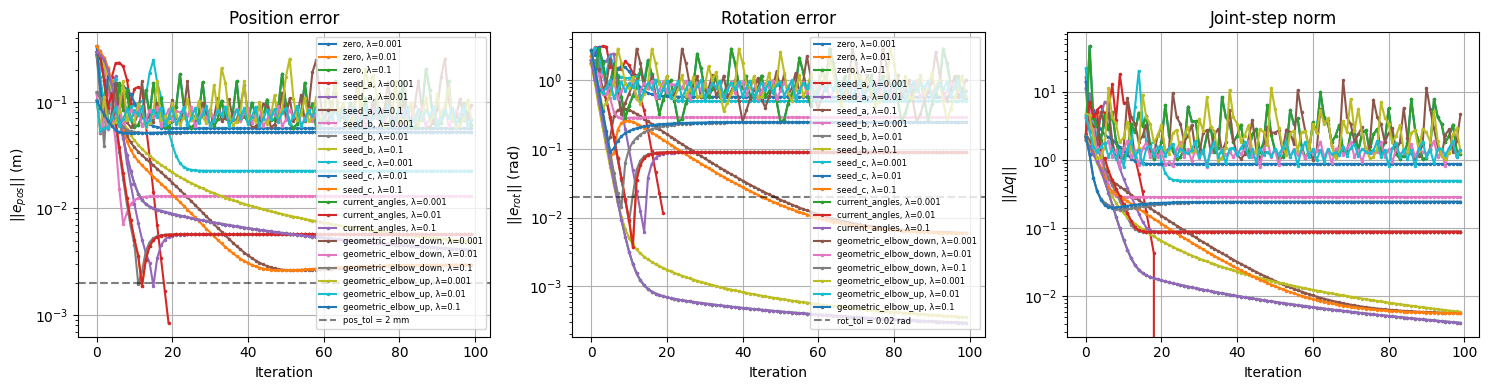

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for run in debug_runs:
    iterations = [entry['iteration'] for entry in run['history']]
    pos_norms = [entry['pos_error_norm'] for entry in run['history']]
    rot_norms = [entry['rot_error_norm'] for entry in run['history']]
    step_norms = [entry['step_norm'] for entry in run['history']]
    label = f"{run['seed']}, λ={run['damping']}"

    axes[0].semilogy(iterations, pos_norms, marker='.', markersize=3, label=label)
    axes[1].semilogy(iterations, rot_norms, marker='.', markersize=3, label=label)
    axes[2].semilogy(iterations, step_norms, marker='.', markersize=3, label=label)

axes[0].set_title('Position error')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel(r'$||e_{pos}||$ (m)')
axes[0].axhline(0.002, color='k', linestyle='--', alpha=0.5, label='pos_tol = 2 mm')
axes[0].grid(True)
axes[0].legend(fontsize=6)

axes[1].set_title('Rotation error')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel(r'$||e_{rot}||$ (rad)')
axes[1].axhline(0.02, color='k', linestyle='--', alpha=0.5, label='rot_tol = 0.02 rad')
axes[1].grid(True)
axes[1].legend(fontsize=6)

axes[2].set_title('Joint-step norm')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel(r'$||\Delta q||$')
axes[2].grid(True)

plt.tight_layout()

**How it works**
- `plt.subplots(1, 3, figsize=(15, 4))` creates one figure with three plots side by side; `axes` is an array of the
  three plot areas.
- **List comprehensions** `[entry['iteration'] for entry in run['history']]` pull one field out of every history
  entry.
- `semilogy` = logarithmic y-axis. Errors that shrink by a constant factor per step form a **straight line** on such a
  plot, so you can see the convergence rate and tiny remaining errors.
- `axhline(0.002, ...)` draws the tolerance as a horizontal line: a curve must go **below** it.
- `plt.tight_layout()` fixes overlapping labels.

**How to read the curves**
| shape | meaning |
|---|---|
| straight downward line | healthy convergence |
| flat plateau, step norm also tiny | **stall**: local minimum, limit, or near-singular pose |
| plateau, step norm stays large | **oscillation**: overshooting; increase damping or shrink `step` |
| error grows | unstable: `step` too big / λ too small near a singularity |

---
## Task 16: The `ik_debug.py` workflow: two targets

pose A: 9 iterations, final pos 1.43 mm, final rot 0.0096 rad
pose B: 200 iterations, final pos 2.67 mm, final rot 0.0001 rad


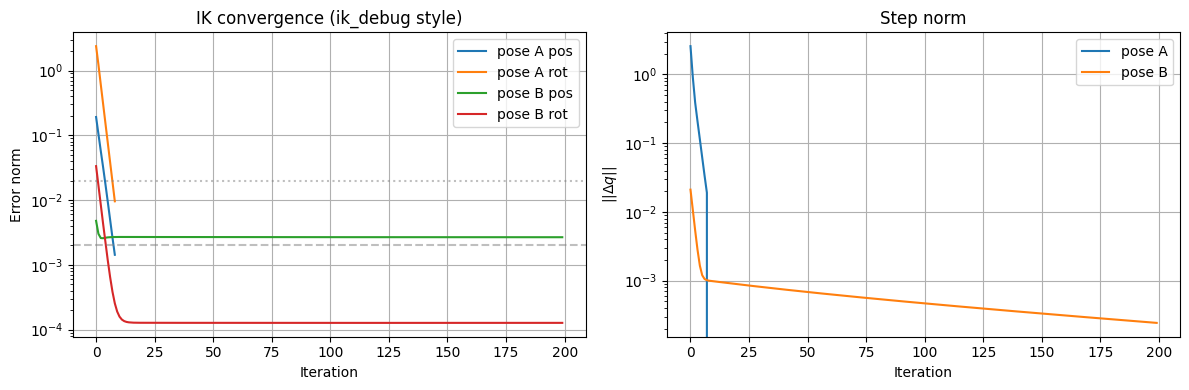

In [24]:
# Two target poses (similar to defaults in ik_debug.py)
pose_a_xyzrpy = [0.0880, -0.0645, 0.2315, 2.337, -0.007, -1.5888]  # m, rad
pose_b_xyzrpy = [0.0502, -0.0639, 0.4194, -1.601, -0.009, -1.5817]  # m, rad

def xyzrpy_to_se3(xyzrpy):
    """Build SE3 from [x, y, z, roll, pitch, yaw] using the codebase RPY convention."""
    return SE3(rpy_to_transform(xyzrpy[:3], xyzrpy[3:6]))

target_a = xyzrpy_to_se3(pose_a_xyzrpy)
target_b = xyzrpy_to_se3(pose_b_xyzrpy)

q0_debug = np.zeros(mycobot.n)

_, hist_a = damped_least_squares_ik(mycobot, bodyname, target_a, q0_debug,
                                     damping=0.05, step=0.5, max_iters=200)
_, hist_b = damped_least_squares_ik(mycobot, bodyname, target_b, q0_debug,
                                     damping=0.05, step=0.5, max_iters=200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy([h['iteration'] for h in hist_a], [h['pos_error_norm'] for h in hist_a], label='pose A pos')
axes[0].semilogy([h['iteration'] for h in hist_a], [h['rot_error_norm'] for h in hist_a], label='pose A rot')
axes[0].semilogy([h['iteration'] for h in hist_b], [h['pos_error_norm'] for h in hist_b], label='pose B pos')
axes[0].semilogy([h['iteration'] for h in hist_b], [h['rot_error_norm'] for h in hist_b], label='pose B rot')
axes[0].set_title('IK convergence (ik_debug style)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Error norm')
axes[0].axhline(0.002, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(0.02, color='gray', linestyle=':', alpha=0.5)
axes[0].legend()
axes[0].grid(True)

axes[1].semilogy([h['iteration'] for h in hist_a], [h['step_norm'] for h in hist_a], label='pose A')
axes[1].semilogy([h['iteration'] for h in hist_b], [h['step_norm'] for h in hist_b], label='pose B')
axes[1].set_title('Step norm')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel(r'$||\Delta q||$')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

for name, hist in (('A', hist_a), ('B', hist_b)):
    print(f"pose {name}: {len(hist)} iterations, final pos {hist[-1]['pos_error_norm']*1000:.2f} mm, "
          f"final rot {hist[-1]['rot_error_norm']:.4f} rad")

**How it works**
- `xyzrpy[:3]` = first three entries (position), `xyzrpy[3:6]` = entries 3–5 (roll, pitch, yaw): list slicing.
- `_, hist_a = f(...)`: the function returns `(q, history)`; the underscore `_` is the conventional name for a value
  you don't need.
- `for name, hist in (('A', hist_a), ('B', hist_b)):` loops over a tuple of pairs and unpacks each pair.
- Two targets with the **same** seed and settings show how **reachability** shapes convergence. Pose A converges in
  9 iterations (1.4 mm, 0.0096 rad: inside both tolerances). Pose B (z = 0.42 m, roughly the height of the
  fully stretched arm) does not: after 200 iterations position is still 2.7 mm off and the error has plateaued.
- Is B unreachable or just hard for this solver? Ask the toolbox solver, which also restarts randomly:

In [25]:
for name, tgt in (('A', target_a), ('B', target_b)):
    q_t, ok, its, srch, res, why = ik_mycobot.solve(mycobot_ets, tgt, q0_debug)
    e_t = calculate_poseerror(q_t, mycobot, bodyname, tgt)
    print(f"pose {name}: toolbox success={ok}, searches={srch}, pos error {np.linalg.norm(e_t[:3])*1000:.2f} mm, "
          f"rot error {np.linalg.norm(e_t[3:]):.4f} rad, reason: {why}")

pose A: toolbox success=True, searches=1, pos error 0.08 mm, rot error 0.0000 rad, reason: Success


pose B: toolbox success=False, searches=100, pos error 5.32 mm, rot error 0.0000 rad, reason: iteration and search limit reached


- If the toolbox solver also fails for B (with all its restarts), B is at or beyond the edge of the workspace with that
  orientation: no seed helps and the answer to "why doesn't it converge" is **reachability**, not tuning.
- Tip for the real robot: check with FK that a target is inside the arm's reach before sending it.

---
## Task 17: Compare the three approaches

In [26]:
best_debug_run = min(debug_runs, key=lambda run: run['final_error'])

solver_summary = {
    'toolbox': {
        'q': transform_to_pipi(q_toolbox),
        'residual_norm': np.linalg.norm(poseerror_toolbox),
    },
    'least_squares_lm': {
        'q': transform_to_pipi(q_lm.x),
        'residual_norm': np.linalg.norm(poseerror_lm),
    },
    'dls_custom': {
        'q': transform_to_pipi(best_debug_run['q']),
        'residual_norm': best_debug_run['final_error'],
        'seed': best_debug_run['seed'],
        'damping': best_debug_run['damping'],
    },
}

solver_summary

{'toolbox': {'q': array([ 2.9265,  0.1337,  2.2295, -0.258 , -0.3117, -1.0927]),
  'residual_norm': 0.0003564402163271501},
 'least_squares_lm': {'q': array([ 2.9258,  0.1319,  2.2276, -0.2545, -0.3121, -1.0919]),
  'residual_norm': 1.3854430726445248e-13},
 'dls_custom': {'q': array([ 0.6211, -1.8697,  0.2608,  2.586 , -0.1548,  1.3462]),
  'residual_norm': 0.004087708910152542,
  'seed': 'zero',
  'damping': 0.1}}

**How it works**
- `min(list, key=lambda run: run['final_error'])`: the element with the smallest `final_error`.
  `lambda run: ...` is a tiny unnamed function that tells `min` what to compare.
- `solver_summary` collects one answer per solver.

**Add timing and a joint-limit check, then compare**

In [27]:
import time

def timed(fn, repeat=5):
    t0 = time.perf_counter()
    for _ in range(repeat):
        out = fn()
    return out, (time.perf_counter() - t0) / repeat

_, t_toolbox = timed(lambda: ik_mycobot.solve(mycobot_ets, target_pose, q0_zero))
_, t_lm = timed(lambda: least_squares(calculate_poseerror, q0_zero, method='lm', ftol=1e-6, xtol=1e-6, gtol=1e-6,
                                       args=(mycobot, bodyname, target_pose)))
_, t_dls = timed(lambda: damped_least_squares_ik(mycobot, bodyname, target_pose, q0_zero, damping=0.1,
                                                 max_iters=100))

print(f"{'solver':18s} {'||e||':>10s} {'time [ms]':>10s} {'within limits':>14s}")
for name, t in (('toolbox', t_toolbox), ('least_squares_lm', t_lm), ('dls_custom', t_dls)):
    s = solver_summary[name]
    print(f"{name:18s} {s['residual_norm']:10.2e} {t*1000:10.1f} {str(within_limits(s['q'])):>14s}")

solver                  ||e||  time [ms]  within limits
toolbox              3.56e-04        8.4           True
least_squares_lm     1.39e-13        5.8           True
dls_custom           4.09e-03       11.3           True


**Discussion (evidence from this run; details change with the URDF)**

| | Toolbox `IK_LM` | `least_squares` (LM) | Custom DLS |
|---|---|---|---|
| Convergence speed | fast (ms) | fast (ms) | slowest: fixed small step, ≤100 iterations, Python loop |
| Final residual | ≈ 4e-4 here (stops at its own `tol`) | ≈ 1e-13 (after wrapping) | ≥ 4 mm here: the best run did not reach the 2 mm tolerance |
| Sensitivity to the seed | low: restarts itself (`searches`), but the branch it lands on varies | medium: no restarts, no limits, local minima | high: 1 of 21 runs converged; stalls at joint limits |
| Joint limits | **respected** | **ignored** (checked afterwards) | respected by clamping |
| Practicality for the robot | good for offline planning | good if limits are checked | what the controller uses: transparent, tunable, no dependencies, streams step by step |

- The **toolbox** solver is the most convenient and robust: it searches from several seeds and stays within limits.
- **`least_squares`** is just as accurate, but you must check the limits yourself.
- The **custom DLS** loop is the least efficient but the most *understandable and controllable*: you choose the
  tolerance, the damping and the step. It is the algorithm inside `mycobot_control` (`_solve_ik`), which is why
  the lab has you build it: in the interview you should be able to explain every line of it.

---
## Task 18: Send an IK solution to the robot
**This cell can move the real arm. It was not executed for the saved version and stays off (`send_ik = False`)
until a person switches it on.**

Problems with the template code, and how the version below handles them:
1. **IK returns *a* solution, not a *close* one.** The toolbox solution here has joint 1 at about 168°. Published
   as it is, the arm would swing there at once (`/mycobot/joint_command` is a single `send_angles` at speed 50,
   with no step limit).
2. `q_best = solver_summary['toolbox']['q']` is a NumPy array: `.tolist()` is right for the message.
3. The robot's current pose is needed to judge the move. So the node also **subscribes** to `/mycobot/joint_states`.

Rule used below: refuse to send if any joint would move more than `max_step_deg` from the measured pose.
If it refuses, solve again with the **current pose as seed** and/or reach the target in small steps (Lab 6).

In [ ]:
import rclpy
from rclpy.node import Node
from sensor_msgs.msg import JointState
from std_msgs.msg import Float64MultiArray

if not rclpy.ok():
    rclpy.init(args=None)


class IKPublisherNode(Node):
    def __init__(self):
        super().__init__('ik_lab_publisher')
        self.pub = self.create_publisher(Float64MultiArray, '/mycobot/joint_command', 10)
        self.last_js = None
        self.sub = self.create_subscription(JointState, '/mycobot/joint_states', self._js_cb, 10)

    def _js_cb(self, msg):
        self.last_js = msg


ik_node = IKPublisherNode()

In [ ]:
def check_joint_target_rad(q_now, q_target, max_step_deg=15.0):
    """Refuse targets outside the joint limits or more than max_step_deg away from q_now (per joint)."""
    q_now = np.asarray(q_now, dtype=float)
    q_target = np.asarray(q_target, dtype=float)
    assert q_target.shape == (6,), "need exactly 6 joint values"
    limits_deg = np.array([[-168, 168], [-135, 135], [-150, 150], [-145, 145], [-165, 165], [-180, 180]])
    lim = np.radians(limits_deg)
    assert np.all((q_target >= lim[:, 0]) & (q_target <= lim[:, 1])), f"outside joint limits: {np.degrees(q_target)}"
    step_deg = np.degrees(transform_to_pipi(q_target - q_now))
    for j in range(6):
        print(f"J{j+1}: {np.degrees(q_now[j]):8.2f} -> {np.degrees(q_target[j]):8.2f} deg  ({step_deg[j]:+.2f})")
    assert np.all(np.abs(step_deg) <= max_step_deg), f"a joint moves more than {max_step_deg} deg"
    return q_target.tolist()


send_ik = False   # a person sets this to True after reading the printed joint table

rclpy.spin_once(ik_node, timeout_sec=1.0)
assert ik_node.last_js is not None, "no joint state: is the controller running?"
q_now = np.array(ik_node.last_js.position, dtype=float)

# IK solution CLOSEST to the current pose: use the current pose as the seed
q_ik, ok, *_ = ik_mycobot.solve(mycobot_ets, target_pose, q_now)
assert ok, "IK failed from the current pose"

msg = Float64MultiArray()
msg.data = check_joint_target_rad(q_now, q_ik, max_step_deg=15.0)   # raises AssertionError if the move is too big

if send_ik:
    ik_node.pub.publish(msg)
    print('Published q =', np.round(msg.data, 4), 'to /mycobot/joint_command')
else:
    print('not sent (send_ik = False)')

rclpy.spin_once(ik_node, timeout_sec=0.5)

# Optional cleanup:
# ik_node.destroy_node()
# rclpy.shutdown()

**How it works**
- The node class is the pattern from Lab 2 (`Node` subclass, publisher, subscription with a callback), plus the
  subscription that stores the measured state.
- `q_ik, ok, *_ = solver(...)`: **star-unpacking**. `q_ik` and `ok` take the first two values, `*_` collects all
  the remaining ones in a list we ignore.
- Solving with `q_now` as the seed makes the solver converge to the solution **nearest** the current pose, so the
  move is as small as the target allows.
- `transform_to_pipi(q_target - q_now)`: wraps the difference into $[-\pi, \pi]$. Without it a joint moving from
  +179° to −179° would look like a 358° step although it is only 2°.
- `check_joint_target_rad` raises `AssertionError` (and nothing is published) for out-of-limit or big moves.
  For the target of Task 4 this will refuse from almost any pose: reaching it needs a big reconfiguration. A
  reachable target close to the current pose is the right test on the real robot.

---
## Summary
- IK = solve $T(q) = T_{target}$ numerically; result depends on the **seed**, may be non-unique or absent, and can
  violate joint limits unless the solver enforces them.
- Error vector = `[Δposition, axis-angle of R_target R_actualᵀ]`, checked with separate tolerances.
- DLS: $\Delta q = J^T(JJ^T + \lambda^2 I)^{-1}e$, $q \leftarrow q + \alpha\Delta q$, clamp to the limits.
- Read convergence plots: line down = good, plateau + tiny step = stall, plateau + big step = oscillation.
- Never send an IK result to the robot without comparing it with the measured pose.